# Market-Impact Models

Trading cost is not summarized by one universal “impact” number. Different models answer different questions about order size, order-book events, and time. This notebook begins with the exact cost of walking a displayed book, then develops three reduced-form descriptions: linear signed-volume impact, order-flow imbalance, and transient impact with resilience.

The organizing question is:

> Which price response are we modeling, over what horizon, and relative to which benchmark?

> **Learning objectives**
>
> By the end of this notebook, we will be able to:
>
> - calculate VWAP, depth slippage, midpoint change, and implementation shortfall from a book walk;
> - distinguish snapshot-dependent mechanical impact from a statistical impact model;
> - estimate a linear signed-volume coefficient and an order-flow-imbalance coefficient;
> - model transient impact and show exactly when slicing an order can reduce execution cost.

Work through the companion order-book-mechanics notebook first. The code below uses the same exact price-time-priority engine.

___

## 1. Measurement comes before modeling

Let \(m_0\) and \(a_0\) be the midpoint and best ask immediately before a buy order. For an executed quantity \(Q\), useful measurements include

$$
\begin{aligned}
\operatorname{VWAP}(Q) &= \frac{1}{Q}\sum_j p_j f_j,\\
\text{depth slippage per share} &= \operatorname{VWAP}(Q)-a_0,\\
\text{implementation shortfall} &=Q\bigl(\operatorname{VWAP}(Q)-m_0\bigr),\\
\text{midpoint change} &=m_+-m_0.
\end{aligned}
$$

These quantities are not interchangeable. VWAP measures received execution prices; midpoint change measures the quoted book after execution; implementation shortfall includes the spread crossed by the trade.

In [1]:
include(joinpath(@__DIR__, "..", "..", "Include.jl"));
using Random;

default(
    fontfamily = "Helvetica",
    framestyle = :box,
    background_color = :gray97,
    background_color_outside = :white,
    legend_background_color = nothing,
    linewidth = 2,
);

function impact_seed_book(; depth_scale::Int = 1)
    book = MyOrderBook(tick_size = 0.01)
    orders = [
        MyLimitOrder(1, Buy,  9_999, 100 * depth_scale),
        MyLimitOrder(2, Buy,  9_998, 150 * depth_scale),
        MyLimitOrder(3, Buy,  9_996, 250 * depth_scale),
        MyLimitOrder(4, Buy,  9_993, 300 * depth_scale),
        MyLimitOrder(5, Sell, 10_001,  80 * depth_scale),
        MyLimitOrder(6, Sell, 10_002, 120 * depth_scale),
        MyLimitOrder(7, Sell, 10_004, 200 * depth_scale),
        MyLimitOrder(8, Sell, 10_007, 300 * depth_scale),
    ]
    foreach(order -> submit_order!(book, order), orders)
    return book
end

function mechanical_buy(quantity::Int; depth_scale::Int = 1)
    book = impact_seed_book(; depth_scale = depth_scale)
    midpoint_before = midprice(book)
    best_ask_before = best_quotes(book).ask
    report = submit_order!(book, MyMarketOrder(Buy, quantity))
    @assert report.executed_quantity == quantity
    @assert validate_order_book(book)
    average_price = execution_vwap(report)
    return (
        order_quantity = quantity,
        vwap = average_price,
        depth_slippage_per_share = average_price - best_ask_before,
        implementation_shortfall = implementation_shortfall(report, midpoint_before),
        midpoint_after = midprice(book),
        midpoint_change = midprice(book) - midpoint_before,
        price_levels_consumed = length(unique(fill.price_ticks for fill in report.fills)),
    )
end

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


mechanical_buy (generic function with 1 method)

## 2. Mechanical impact: walk identical book snapshots

The clean experiment resets the same book before every order and changes only \(Q\). The resulting curve is deterministic: it is a transformation of the displayed ask schedule, not an empirical law.

In [2]:
order_sizes = [10, 40, 80, 100, 150, 200, 300, 400, 500, 600]
mechanical_results = DataFrame([mechanical_buy(quantity) for quantity in order_sizes])
mechanical_results

Row,order_quantity,vwap,depth_slippage_per_share,implementation_shortfall,midpoint_after,midpoint_change,price_levels_consumed
,Int64,Float64,Float64,Float64,Float64,Float64,Int64
1,10,100.01,0.0,0.1,100.0,0.0,1
2,40,100.01,0.0,0.4,100.0,0.0,1
3,80,100.01,0.0,0.8,100.005,0.005,1
4,100,100.012,0.002,1.2,100.005,0.005,2
5,150,100.015,0.00466667,2.2,100.005,0.005,2
6,200,100.016,0.006,3.2,100.015,0.015,2
7,300,100.024,0.014,7.2,100.015,0.015,3
8,400,100.028,0.018,11.2,100.03,0.03,3
9,500,100.036,0.0264,18.2,100.03,0.03,4


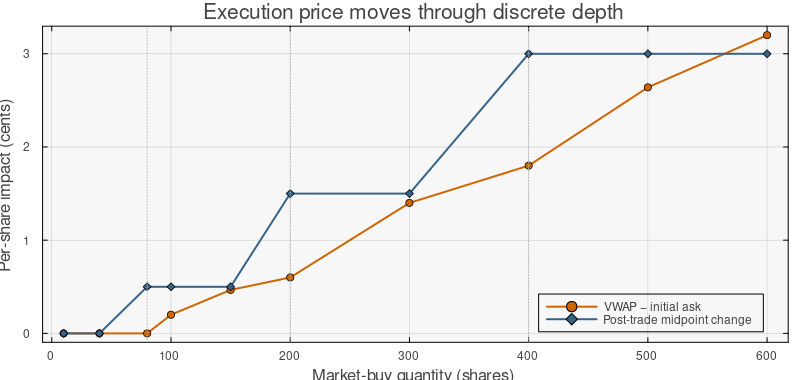

In [3]:
p1 = plot(
    mechanical_results.order_quantity,
    100 .* mechanical_results.depth_slippage_per_share;
    marker = :circle, color = :darkorange3, label = "VWAP − initial ask",
    xlabel = "Market-buy quantity (shares)", ylabel = "Per-share impact (cents)",
    title = "Execution price moves through discrete depth", size = (800, 380),
)
plot!(p1, mechanical_results.order_quantity,
    100 .* mechanical_results.midpoint_change;
    marker = :diamond, color = :steelblue4, label = "Post-trade midpoint change")
for boundary in (80, 200, 400)
    vline!(p1, [boundary]; color = :gray70, linewidth = 1, linestyle = :dot, label = "")
end
p1

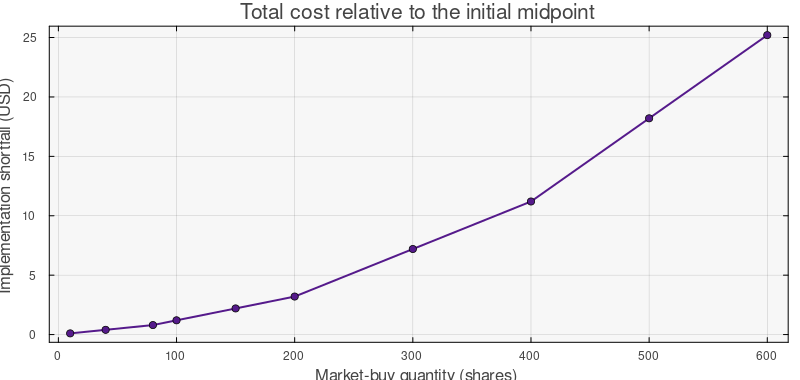

In [4]:
p2 = plot(
    mechanical_results.order_quantity,
    mechanical_results.implementation_shortfall;
    marker = :circle, color = :purple4, label = "",
    xlabel = "Market-buy quantity (shares)", ylabel = "Implementation shortfall (USD)",
    title = "Total cost relative to the initial midpoint", size = (800, 380),
)
p2

The flat segments occur while an order is only partially consuming one price level. A jump occurs when the order reaches a worse level. Implementation shortfall grows faster than quantity because larger orders both buy more shares and pay worse marginal prices.

This experiment conditions on one displayed snapshot. It omits hidden liquidity, new limit orders, cancellations during execution, information, and strategic response. We should therefore call it **mechanical book-walking impact**, not a universal market-impact function.

### The same order has different impact in a different state

Impact is large relative to available depth, not simply because the share count is large. We compare the same 300-share order in the baseline book and in a book with three times as much quantity at every price.

In [5]:
state_comparison = DataFrame([
    merge((book_state = "Baseline depth",), mechanical_buy(300; depth_scale = 1)),
    merge((book_state = "Three-times depth",), mechanical_buy(300; depth_scale = 3)),
])
select(state_comparison, :book_state, :order_quantity, :vwap,
    :depth_slippage_per_share, :midpoint_change, :implementation_shortfall)

Row,book_state,order_quantity,vwap,depth_slippage_per_share,midpoint_change,implementation_shortfall
,String,Int64,Float64,Float64,Float64,Float64
1,Baseline depth,300,100.024,0.014,0.015,7.2
2,Three-times depth,300,100.012,0.002,0.005,3.6


The quantity is identical, but the deeper book absorbs it closer to the initial quote. This is why an impact coefficient must be interpreted together with liquidity and sampling horizon.

## 3. Linear signed-volume impact

A common reduced-form benchmark is

$$
\Delta m_t=\lambda q_t+\varepsilon_t,
$$

where \(q_t>0\) denotes buyer-initiated volume, \(q_t<0\) denotes seller-initiated volume, and \(\lambda\) has units of price change per signed share. In Kyle's equilibrium model, the related slope summarizes price sensitivity to order flow and market depth. Here we use the equation as a statistical benchmark and estimate it by least squares through the origin:

$$
\widehat\lambda=\frac{\sum_t q_t\Delta m_t}{\sum_t q_t^2}.
$$

Reference: Albert S. Kyle, [“Continuous Auctions and Insider Trading”](https://doi.org/10.2307/1913210), *Econometrica* 53(6), 1985.

In [6]:
Random.seed!(5660)
number_of_windows = 400
signed_volume = rand(-500:500, number_of_windows)
lambda_true = 2.5e-5                         # USD per signed share
midpoint_noise = 0.004 .* randn(number_of_windows)
midpoint_change = lambda_true .* signed_volume .+ midpoint_noise
lambda_hat = dot(signed_volume, midpoint_change) / dot(signed_volume, signed_volume)

linear_fit_summary = DataFrame(
    parameter = ["True λ", "Estimated λ"],
    value_USD_per_signed_share = [lambda_true, lambda_hat],
)
linear_fit_summary

Row,parameter,value_USD_per_signed_share
,String,Float64
1,True λ,2.5e-5
2,Estimated λ,2.44374e-5


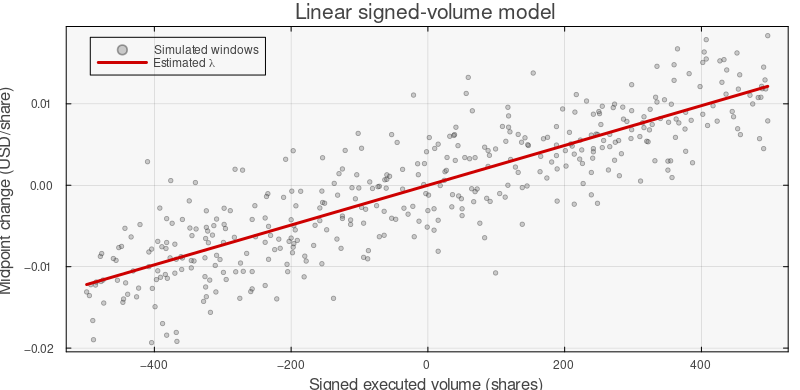

In [7]:
volume_grid = range(extrema(signed_volume)...; length = 200)
scatter(
    signed_volume, midpoint_change;
    markersize = 2.5, markeralpha = 0.35, color = :gray45, label = "Simulated windows",
    xlabel = "Signed executed volume (shares)", ylabel = "Midpoint change (USD/share)",
    title = "Linear signed-volume model", size = (800, 390),
)
plot!(volume_grid, lambda_hat .* volume_grid;
    color = :red3, linewidth = 3, label = "Estimated λ")

The fitted line averages across many event windows. Unlike the staircase produced by a single book snapshot, it is a reduced-form conditional expectation. Its slope depends on how trades are signed, the time interval used to aggregate them, and the liquidity regime represented in the data.

## 4. Order-flow imbalance includes non-trade events

Short-horizon prices respond to changes in supply and demand at the quotes, not only to completed trades. A simple best-quote order-flow-imbalance convention assigns

- positive contribution to quantity added at the bid or removed from the ask;
- negative contribution to quantity removed from the bid or added at the ask.

Thus, limit orders and cancellations enter the same state-change measure as executions. Over window \(k\),

$$
\operatorname{OFI}_k=\sum_{n\in k}e_n,
\qquad
\Delta m_k=\beta\operatorname{OFI}_k+\epsilon_k.
$$

Reference: Rama Cont, Arseniy Kukanov, and Sasha Stoikov, [“The Price Impact of Order Book Events”](https://doi.org/10.1093/jjfinec/nbt003), *Journal of Financial Econometrics* 12(1), 2014.

In [8]:
events = DataFrame(
    window = repeat(1:6, inner = 4),
    book_side = repeat(["bid", "ask", "bid", "ask"], 6),
    action = repeat(["add", "add", "remove", "remove"], 6),
    quantity = [80, 35, 20, 60, 45, 90, 70, 15, 110, 20, 30, 85,
                30, 75, 95, 25, 70, 45, 10, 100, 40, 105, 55, 35],
)

function signed_ofi_event(side::String, action::String, quantity::Int)
    if (side == "bid" && action == "add") || (side == "ask" && action == "remove")
        return quantity
    end
    return -quantity
end

events.ofi_contribution = [
    signed_ofi_event(row.book_side, row.action, row.quantity) for row in eachrow(events)
]

ofi_windows = combine(groupby(events, :window), :ofi_contribution => sum => :ofi)
beta_true = 4.0e-5
ofi_windows.midpoint_change = beta_true .* ofi_windows.ofi .+
    [0.0005, -0.0003, 0.0002, -0.0004, 0.0001, -0.0002]
beta_hat = dot(ofi_windows.ofi, ofi_windows.midpoint_change) /
    dot(ofi_windows.ofi, ofi_windows.ofi)

(events = events, window_estimates = ofi_windows,
    estimated_beta = beta_hat)

(events = 24×5 DataFrame
 Row │ window  book_side  action  quantity  ofi_contribution 
     │ Int64   String     String  Int64     Int64            
─────┼───────────────────────────────────────────────────────
   1 │      1  bid        add           80                80
   2 │      1  ask        add           35               -35
   3 │      1  bid        remove        20               -20
   4 │      1  ask        remove        60                60
   5 │      2  bid        add           45                45
   6 │      2  ask        add           90               -90
   7 │      2  bid        remove        70               -70
   8 │      2  ask        remove        15                15
   9 │      3  bid        add          110               110
  10 │      3  ask        add           20               -20
  11 │      3  bid        remove        30               -30
  ⋮  │   ⋮         ⋮        ⋮        ⋮             ⋮
  15 │      4  bid        remove        95               -95
  16

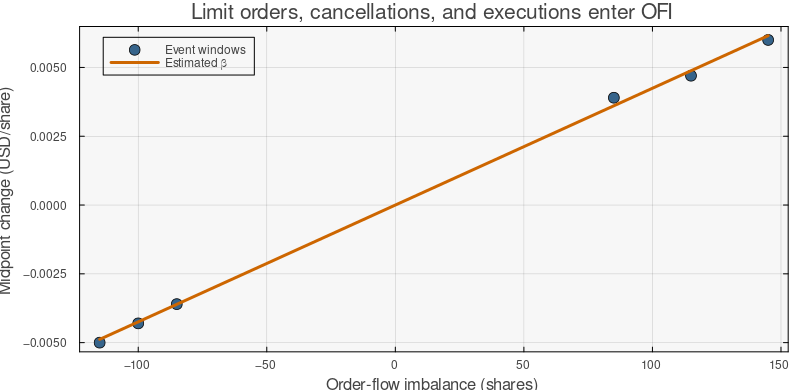

In [9]:
ofi_grid = range(extrema(ofi_windows.ofi)...; length = 100)
scatter(
    ofi_windows.ofi, ofi_windows.midpoint_change;
    marker = :circle, markersize = 6, color = :steelblue4, label = "Event windows",
    xlabel = "Order-flow imbalance (shares)", ylabel = "Midpoint change (USD/share)",
    title = "Limit orders, cancellations, and executions enter OFI", size = (800, 390),
)
plot!(ofi_grid, beta_hat .* ofi_grid;
    color = :darkorange3, linewidth = 3, label = "Estimated β")

OFI is closer to the book's event mechanics than trade volume alone. An ask cancellation and an aggressive buy both remove displayed ask quantity, so both contribute positive pressure under this convention. The model remains an empirical window-level relationship; it is not a claim that every event causes the fitted price change in isolation.

## 5. Transient impact and resilience

A static book cannot explain what happens while an order is split over time. Introduce an impact state \(x_k\) and trading quantity \(u_k\):

$$
x_{k+1}=\rho\bigl(x_k+\eta u_k\bigr),
\qquad 0\leq\rho\leq1.
$$

The trade moves impact from \(x_k\) to \(x_k+\eta u_k\); the average execution impact during that trade is \(x_k+\tfrac12\eta u_k\). Between decisions, only the fraction \(\rho\) remains. Small \(\rho\) represents fast resilience; \(\rho=1\) represents no decay.

This abstraction follows the central insight of Obizhaeva and Wang: execution depends on dynamic liquidity replenishment, not only static spread and depth. See [“Optimal Trading Strategy and Supply/Demand Dynamics”](https://doi.org/10.1016/j.finmar.2012.09.001), *Journal of Financial Markets* 16(1), 2013.

In [10]:
function transient_execution(schedule::Vector{Int}; rho::Float64, eta::Float64)
    impact_before = 0.0
    rows = NamedTuple[]
    total_cost = 0.0
    for (step, quantity) in enumerate(schedule)
        average_execution_impact = impact_before + 0.5 * eta * quantity
        total_cost += quantity * average_execution_impact
        impact_after_trade = impact_before + eta * quantity
        impact_after_decay = rho * impact_after_trade
        push!(rows, (
            step = step,
            quantity = quantity,
            impact_before = impact_before,
            average_execution_impact = average_execution_impact,
            impact_after_trade = impact_after_trade,
            impact_after_decay = impact_after_decay,
        ))
        impact_before = impact_after_decay
    end
    return (path = DataFrame(rows), total_cost = total_cost)
end

total_quantity = 450
block_schedule = [450, 0, 0, 0, 0]
sliced_schedule = fill(90, 5)
eta = 5.0e-5

no_decay_block = transient_execution(block_schedule; rho = 1.0, eta = eta)
no_decay_sliced = transient_execution(sliced_schedule; rho = 1.0, eta = eta)
resilient_block = transient_execution(block_schedule; rho = 0.55, eta = eta)
resilient_sliced = transient_execution(sliced_schedule; rho = 0.55, eta = eta)

cost_comparison = DataFrame(
    liquidity_dynamics = ["No decay", "No decay", "Resilient", "Resilient"],
    schedule = ["Block", "Five slices", "Block", "Five slices"],
    total_quantity = fill(total_quantity, 4),
    impact_cost = [no_decay_block.total_cost, no_decay_sliced.total_cost,
        resilient_block.total_cost, resilient_sliced.total_cost],
)
cost_comparison

Row,liquidity_dynamics,schedule,total_quantity,impact_cost
,String,String,Int64,Float64
1,No decay,Block,450,5.0625
2,No decay,Five slices,450,5.0625
3,Resilient,Block,450,5.0625
4,Resilient,Five slices,450,2.44286


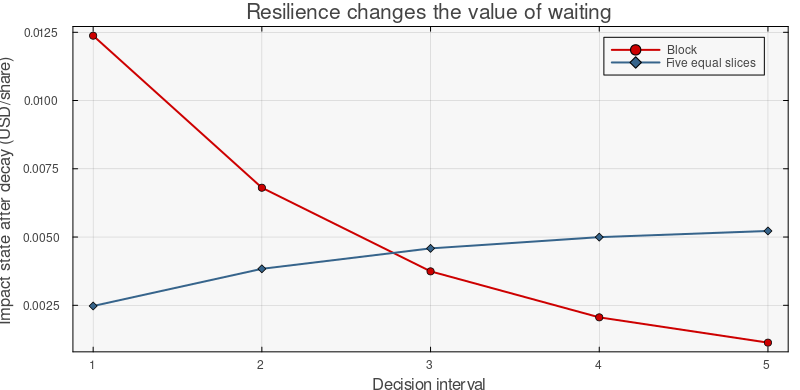

In [11]:
plot(
    resilient_block.path.step, resilient_block.path.impact_after_decay;
    marker = :circle, color = :red3, label = "Block",
    xlabel = "Decision interval", ylabel = "Impact state after decay (USD/share)",
    title = "Resilience changes the value of waiting", size = (800, 390),
    xticks = 1:5,
)
plot!(resilient_sliced.path.step, resilient_sliced.path.impact_after_decay;
    marker = :diamond, color = :steelblue4, label = "Five equal slices")

When \(\rho=1\), splitting does not reduce total mechanical impact cost: the later slices inherit all impact created by the earlier ones. When \(\rho<1\), impact partially decays between slices, so waiting can reduce modeled cost.

This is not yet an optimal-execution result. Waiting also exposes the unexecuted position to price risk, and a complete optimization must specify that risk, the deadline, and the admissible schedules. The current experiment isolates the role of resilience.

## Model map

| Description | Input | Output | Appropriate interpretation |
|:--|:--|:--|:--|
| Displayed-book walk | One book snapshot and order size | Fills, VWAP, shortfall, new book | Immediate mechanical execution cost |
| Linear signed volume | Signed executed volume over a window | Conditional midpoint change | Reduced-form average price sensitivity |
| Order-flow imbalance | Limit additions, cancellations, and executions | Short-window midpoint change | Net pressure at the quoted book |
| Transient impact | Trade schedule and resilience parameters | Impact path and schedule cost | Dynamic cost when liquidity recovers |

The models are complementary rather than interchangeable. A book walk is exact conditional on its snapshot but silent about recovery. A regression describes average data behavior but suppresses queue detail. A transient model supplies dynamics but requires assumptions about resilience.

## Summary

Market impact is a family of measurements and models whose meaning depends on the book state, event aggregation, and time horizon.

> **Key takeaways**
>
> - **Mechanical impact is state dependent:** resetting the same book reveals a discrete depth curve, while changing book depth changes the cost of the same order.
> - **Order flow is broader than trade volume:** limit orders and cancellations alter supply and demand and belong in short-horizon imbalance measures.
> - **Slicing requires resilience to help:** splitting is cost-equivalent in a non-replenishing book; its benefit arises only when impact decays or liquidity returns between trades.

A credible execution study must therefore name its benchmark, horizon, event convention, and liquidity dynamics before interpreting an impact coefficient.

___